In [24]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, recall_score, make_scorer
import pandas as pd
import shap
import matplotlib.pyplot as plt


# Data odniesienia: koniec 2009 roku
reference_date = pd.to_datetime('2009-12-31')

train_beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
train_inpatientdata = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
train_outpatientdata = pd.read_csv('Train_Outpatientdata-1542865627584.csv')
train_claims = pd.concat([train_inpatientdata, train_outpatientdata], axis=0)

train_claims_with_beneficiary = train_claims.merge(train_beneficiary, on='BeneID', how='left')
train_claims_with_beneficiary['DOB'] = pd.to_datetime(train_claims_with_beneficiary['DOB'], errors='coerce')

train_provider = pd.read_csv('Train-1542865627584.csv')
train_provider['FraudFlag'] = train_provider['PotentialFraud'].map({'Yes': 1, 'No': 0})
all_data= train_claims_with_beneficiary.merge(train_provider, on='Provider', how='left')

all_data['Age'] = ((reference_date - train_claims_with_beneficiary['DOB']).dt.days // 365).astype(int)
all_data['WasOperated'] = all_data['OperatingPhysician'].notna().astype(int)

cols = [
    'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
    'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
    'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
    'ClmDiagnosisCode_10'
]

all_data['RenalDiseaseIndicator'] = (all_data['RenalDiseaseIndicator'] == 'Y').astype(int)
all_data['DiagnosisCount'] = all_data[cols].notnull().sum(axis=1)
all_data['ProceduresCount'] = all_data[cols].notnull().sum(axis=1)

numeric_features = [
    'InscClaimAmtReimbursed', 'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
    'IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt',
    'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt',
    'Age', 'DiagnosisCount', 'ProceduresCount', 'WasOperated'
]

categorical_features = ['Gender', 'Race', 'RenalDiseaseIndicator']

X = all_data[numeric_features + categorical_features]
y = all_data['FraudFlag']
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=random_state)

print("Train samples: {}.".format(X_train.shape[0]))
print("Test samples: {}.".format(X_test.shape[0]))


Train samples: 446568.
Test samples: 111643.


In [45]:
all_data.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,FraudFlag,Age,WasOperated,DiagnosisCount,ProceduresCount
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,36000,3204,60,70,Yes,1,67,0,9,9
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,36000,3204,60,70,No,0,67,1,3,3
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,36000,3204,60,70,No,0,67,0,6,6
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,5000,1068,250,320,No,0,95,1,9,9
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,21260,2136,120,100,No,0,71,1,9,9


In [25]:

print(X['RenalDiseaseIndicator'].value_counts(dropna=False))

RenalDiseaseIndicator
0    448363
1    109848
Name: count, dtype: int64


In [26]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='error', random_state=random_state)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [29]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.94      0.64      0.76    102045
           1       0.14      0.60      0.22      9598

    accuracy                           0.64    111643
   macro avg       0.54      0.62      0.49    111643
weighted avg       0.88      0.64      0.72    111643



📊 Metryki klasyfikacji:
Klasa 0 (Nieoszustwo)
Precision (precyzja): 0.95 – bardzo dobrze, model rzadko błędnie klasyfikuje fraudy jako nie-fraudy.

Recall (czułość): 0.64 – tylko 64% nie-fraudów zostało poprawnie rozpoznanych.

F1-score: 0.76 – wynik kompromisowy (dobry, ale nie idealny).

Klasa 1 (Oszustwo / Fraud)
Precision: 0.14 – bardzo niska, czyli:

spośród wykrytych fraudów większość to fałszywe alarmy.

Recall: 0.61 – to największy sukces, bo udało się wykryć 61% prawdziwych fraudów!

F1-score: 0.22 – niski, bo precision ciągnie wynik w dół.

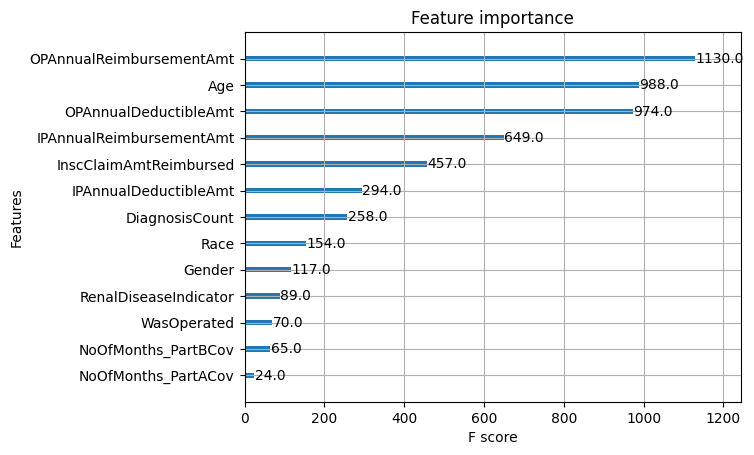

In [14]:
xgboost.plot_importance(model)

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
model = XGBClassifier(eval_metric='error', random_state=random_state)
accuracy_res = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

In [17]:
print(accuracy_res)

[0.63669016 0.63614052 0.63770803 0.63677648 0.63631071]


In [ ]:
#Optymalizacja hiperparametrów modelu (np. za pomocą GridSearchCV)

In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

parameters = {
    'max_depth': range (2, 10, 2),
    'n_estimators': [100],
    'learning_rate': [0.1, 0.05],
    'colsample_bytree': [0.8, 0.9, 1]
}
model = XGBClassifier(eval_metric='error', random_state=random_state)
grid_obj = GridSearchCV(estimator=model, param_grid=parameters, scoring='accuracy', cv=skf)
grid_fit = grid_obj.fit(X_train, y_train)

In [19]:
cv_df = pd.concat([pd.DataFrame(grid_fit.cv_results_['params']), pd.DataFrame(grid_fit.cv_results_['mean_test_score']).rename(columns={0:'Accuracy'})], axis = 1)

In [20]:
cv_df.sort_values(by='Accuracy', ascending=False)

,colsample_bytree,learning_rate,max_depth,n_estimators,Accuracy
19,1.0,0.10,8,100,0.633895
11,0.9,0.10,8,100,0.633465
3,0.8,0.10,8,100,0.633097
7,0.8,0.05,8,100,0.631344
18,1.0,0.10,6,100,0.631322
23,1.0,0.05,8,100,0.631301
15,0.9,0.05,8,100,0.631198
2,0.8,0.10,6,100,0.630903
10,0.9,0.10,6,100,0.630901
22,1.0,0.05,6,100,0.630115


In [ ]:
#Mamy minimalne róznice

In [21]:
grid_fit.best_params_

{'colsample_bytree': 1,
 'learning_rate': 0.1,
 'max_depth': 8,
 'n_estimators': 100}

In [22]:
best_clf = grid_fit.best_estimator_
y_pred = best_clf.predict(X_test)

In [23]:
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.95      0.64      0.76    103034
           1       0.12      0.61      0.20      8609

    accuracy                           0.64    111643
   macro avg       0.54      0.62      0.48    111643
weighted avg       0.89      0.64      0.72    111643



In [ ]:
# probuje analize tych z cechami najwazniejszymi

In [31]:
# Lista najważniejszych cech z wykresu
important_features = [
    'OPAnnualReimbursementAmt',
    'Age',
    'OPAnnualDeductibleAmt',
    'IPAnnualReimbursementAmt',
    'InscClaimAmtReimbursed',
    'IPAnnualDeductibleAmt',
    'DiagnosisCount',
    'Race',
    'Gender',
    'RenalDiseaseIndicator',
    'WasOperated',
    'NoOfMonths_PartBCov',
    'NoOfMonths_PartACov',
    'FraudFlag'  # target
]

# Redukcja DataFrame'u
all_important_data = all_data[important_features]

X_imp = all_important_data[important_features[:-1]]
y_imp = all_important_data['FraudFlag']
random_state = 42
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=random_state)


Train samples: 446568.
Test samples: 111643.


In [32]:
model = XGBClassifier(eval_metric='error', random_state=random_state)
model.fit(X_train_imp, y_train_imp)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [33]:
y_pred_imp = model.predict(X_test_imp)

In [34]:
print(classification_report(y_pred_imp, y_test_imp))

              precision    recall  f1-score   support

           0       0.94      0.64      0.76    102045
           1       0.14      0.60      0.22      9598

    accuracy                           0.64    111643
   macro avg       0.54      0.62      0.49    111643
weighted avg       0.88      0.64      0.72    111643



In [ ]:
# Nie ma zauważalnej różnicy

In [ ]:
# Undersampling z SMOTE

In [38]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

X = all_important_data.drop('FraudFlag', axis=1)
y = all_important_data['FraudFlag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(y_train_rus.value_counts())

FraudFlag
0    170236
1    170236
Name: count, dtype: int64


In [39]:
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.66      0.73      0.69     69083
           1       0.47      0.39      0.43     42560

    accuracy                           0.60    111643
   macro avg       0.57      0.56      0.56    111643
weighted avg       0.59      0.60      0.59    111643

ROC AUC: 0.5925764540521106


In [ ]:
#SMote poprawiło recall dla klasy 0 a pogorszylo dla 1 co nie jest korzystne dla nas

In [40]:
# probuje zmienic sample weight

In [42]:
from sklearn.utils import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(eval_metric='error',
 colsample_bytree=0.8,
 learning_rate = 0.1,
 max_depth = 2,
 n_estimators = 100, random_state=random_state)
model.fit(X_train, y_train, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='error', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [43]:
y_pred = model.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.88      0.74     69083
           1       0.50      0.19      0.28     42560

    accuracy                           0.62    111643
   macro avg       0.57      0.54      0.51    111643
weighted avg       0.58      0.62      0.56    111643



In [ ]:
#Jeszcze bardziej sie polepszyl recall dla 0 ale dla 1 bardzo slabo

In [ ]:


# 1. Zmiana progu decyzyjnego
# Najpierw trenujemy model (możesz użyć najlepszego modelu z GridSearchCV lub innego)
model = XGBClassifier(
    eval_metric='logloss', # Możesz użyć logloss lub innego
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=2,
    n_estimators=100,
    random_state=random_state
)
model.fit(X_train, y_train)

# Uzyskanie prawdopodobieństw
y_proba = model.predict_proba(X_test)[:, 1]

# Próba różnych progów decyzyjnych
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5] # Możesz eksperymentować z innymi progami

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    print(f"Threshold: {threshold}")
    print(classification_report(y_test, y_pred_threshold))
    print("-" * 30)

# 2. Oversampling z SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Rozkład klas po SMOTE:")
print(y_train_smote.value_counts())

model_smote = XGBClassifier(eval_metric='logloss', random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

print("\nClassification Report po SMOTE:")
print(classification_report(y_test, y_pred_smote))
print("ROC AUC po SMOTE:", roc_auc_score(y_test, y_proba_smote))

# 4. Użycie scale_pos_weight
# Obliczenie scale_pos_weight
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"\nscale_pos_weight: {scale_pos_weight_value}")

model_weighted = XGBClassifier(
    eval_metric='logloss', # Zmień metrykę na logloss lub inną odpowiednią
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=2,
    n_estimators=100,
    random_state=random_state,
    scale_pos_weight=scale_pos_weight_value
)

model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)
y_proba_weighted = model_weighted.predict_proba(X_test)[:, 1]

print("\nClassification Report z scale_pos_weight:")
print(classification_report(y_test, y_pred_weighted))
print("ROC AUC z scale_pos_weight:", roc_auc_score(y_test, y_proba_weighted))

# 5. Strojenie hiperparametrów pod kątem recall (dla klasy 1) lub F1-score
recall_scorer = make_scorer(recall_score, pos_label=1) # pos_label=1 określa, dla której klasy liczymy recall

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

parameters_recall = {
    'max_depth': range(2, 6, 1), # mniejszy zakres, żeby było szybciej
    'n_estimators': [100, 150],
    'learning_rate': [0.1, 0.05],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [1, scale_pos_weight_value] #  scale_pos_weight do gridu
}

model_gs_recall = XGBClassifier(eval_metric='logloss', random_state=random_state

grid_obj_recall = GridSearchCV(estimator=model_gs_recall, param_grid=parameters_recall, scoring=recall_scorer, cv=skf, verbose=1) # Zmieniony scoring
grid_fit_recall = grid_obj_recall.fit(X_train, y_train)

print("\nBest parameters for Recall (Class 1):", grid_fit_recall.best_params_)

best_clf_recall = grid_fit_recall.best_estimator_
y_pred_gs_recall = best_clf_recall.predict(X_test)
y_proba_gs_recall = best_clf_recall.predict_proba(X_test)[:, 1]

print("\nClassification Report z GridSearchCV (scoring=recall):")
print(classification_report(y_test, y_pred_gs_recall))
print("ROC AUC z GridSearchCV (scoring=recall):", roc_auc_score(y_test, y_proba_gs_recall))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     69083
           1       0.38      1.00      0.55     42560

    accuracy                           0.38    111643
   macro avg       0.19      0.50      0.28    111643
weighted avg       0.15      0.38      0.21    111643

------------------------------
Threshold: 0.2
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     69083
           1       0.38      1.00      0.55     42560

    accuracy                           0.38    111643
   macro avg       0.19      0.50      0.28    111643
weighted avg       0.15      0.38      0.21    111643

------------------------------
Threshold: 0.3
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     69083
           1       0.38      1.00      0.55     42560

    accuracy                           0.38    111643
   macro avg       0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.64      0.89      0.74     69083
           1       0.50      0.18      0.27     42560

    accuracy                           0.62    111643
   macro avg       0.57      0.54      0.50    111643
weighted avg       0.59      0.62      0.56    111643

------------------------------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.63      0.95      0.76     69083
           1       0.57      0.10      0.17     42560

    accuracy                           0.63    111643
   macro avg       0.60      0.53      0.46    111643
weighted avg       0.61      0.63      0.53    111643

------------------------------
Rozkład klas po SMOTE:
FraudFlag
0    276332
1    276332
Name: count, dtype: int64

Classification Report po SMOTE:
              precision    recall  f1-score   support

           0       0.64      0.81      0.72     69083
           1       0.46      0.27      0.34 